<a href="https://colab.research.google.com/github/OdinakaDico/Oasis3_dementia_classification_project/blob/main/Oasis3_dementia_v2_axis1(Coronal_like_view2keepthis_very_important).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(torch.cuda.is_available())

Mounted at /content/drive
True


In [22]:
old_data_dir = "/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1"
data_dir = "/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1_cleaned"

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import pandas as pd

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


In [24]:
class AddGaussianNoise(object):

    def __init__(self, mean=0.0, std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):

        tensor = (
            tensor
            + torch.randn_like(tensor) * self.std
            + self.mean
        )

        return torch.clamp(
            tensor,
            0.0,
            1.0
        )

In [25]:
# =====================================
# DEVICE
# =====================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


#### Slices were extracted corresponding to a coronal-like view after preprocessing.

- Dataset Version: V2, Axis 1
- Normal Subject: 105
- Dementia Subject: 105
- Train-set:        
  - Normal Subject (84)
  - Dementia Subject (84)
- Validation-Set:
  - Normal Subject (21)
  - Dementia Subject (21)



In [26]:
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1_cleaned"))

['train', 'val']


In [27]:


records = []

for split in ["train", "val"]:
    for label in ["normal", "dementia"]:

        label_path = os.path.join(data_dir, split, label)

        for subject in os.listdir(label_path):

            subject_path = os.path.join(label_path, subject)

            png_count = len([
                f for f in os.listdir(subject_path)
                if f.endswith(".png")
            ])

            records.append({
                "split": split,
                "label": label,
                "subject": subject,
                "num_slices": png_count
            })

slice_count_df = pd.DataFrame(records)
problem_subjects = slice_count_df[slice_count_df["num_slices"] != 100]

print(problem_subjects)

print(slice_count_df.head())

print("\nTotal subjects:", len(slice_count_df))
print("Total slices:", slice_count_df["num_slices"].sum())

     split     label   subject  num_slices
0    train    normal  OAS30113         101
1    train    normal  OAS31161         101
2    train    normal  OAS31145          96
3    train    normal  OAS31113          99
4    train    normal  OAS31090          98
..     ...       ...       ...         ...
205    val  dementia  OAS30316         101
206    val  dementia  OAS30130          97
207    val  dementia  OAS30394         101
208    val  dementia  OAS30358          97
209    val  dementia  OAS30158          98

[177 rows x 4 columns]
   split   label   subject  num_slices
0  train  normal  OAS30113         101
1  train  normal  OAS31161         101
2  train  normal  OAS31145          96
3  train  normal  OAS31113          99
4  train  normal  OAS31090          98

Total subjects: 210
Total slices: 20592


In [28]:
# =====================================
# MODEL
# =====================================

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# classifier
model.fc = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(
        model.fc.in_features,
        2
    )
)

model = model.to(device)


In [29]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# load pretrained ResNet18 (NEW WAY)
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# replace final layer (VERY IMPORTANT)
model.fc = nn.Linear(model.fc.in_features, 2)

# move to GPU
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
# =====================================
# LOSS FUNCTION
# =====================================

class_weights = torch.tensor(
    [1.2, 1.0],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# =====================================
# OPTIMIZER
# =====================================

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)


In [31]:
# =====================================
# LEARNING RATE SCHEDULER
# =====================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


In [32]:
# =====================================
# DATA AUGMENTATION
# =====================================

train_transforms = transforms.Compose([
    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    transforms.RandomRotation(20),

    transforms.RandomHorizontalFlip(),

    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor(),
       AddGaussianNoise(
        mean=0.0,
        std=0.01
    ),


])

val_transforms = transforms.Compose([
    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

])


/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1_cleaned/train/dementia/OAS31067/OAS31067_axis1_slice_140.png


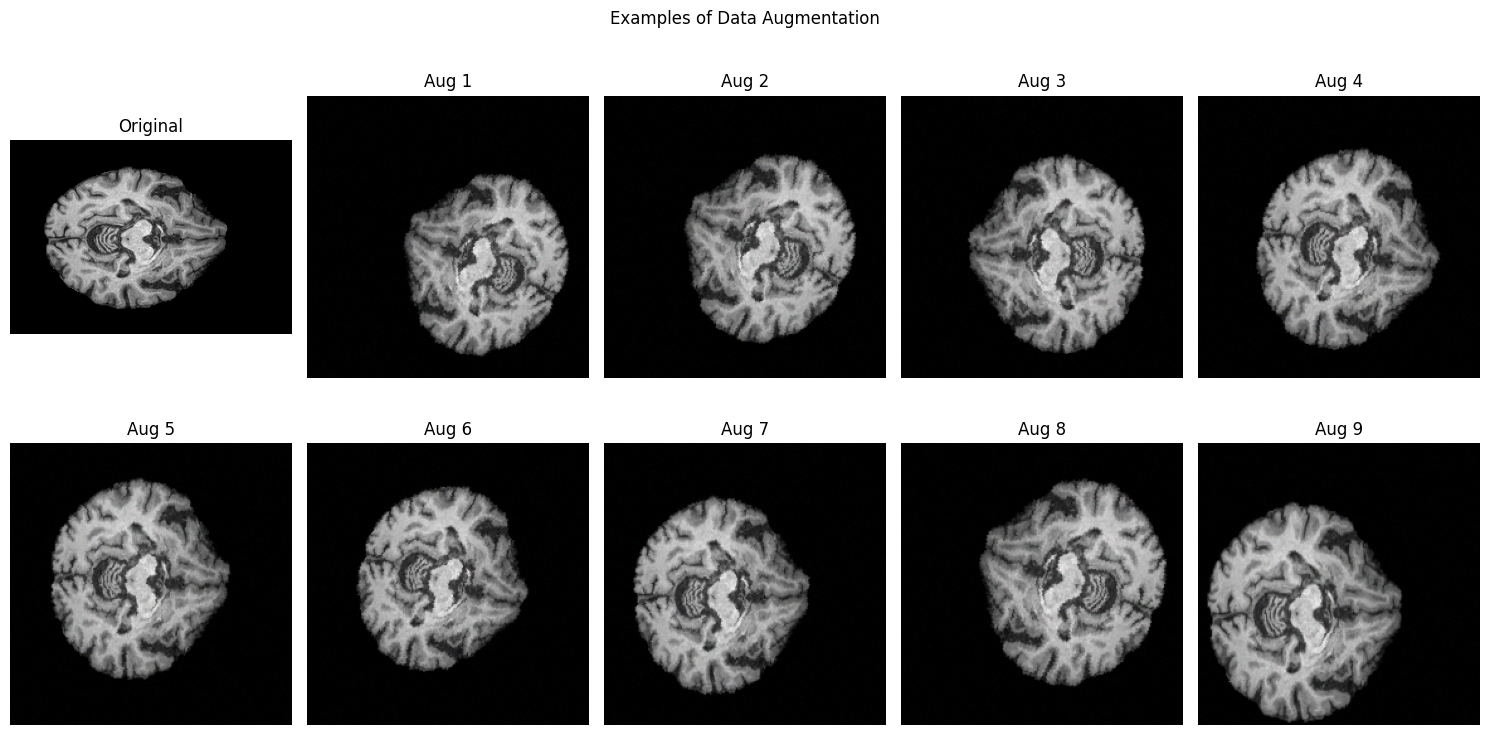

In [33]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Pick one subject and one hippocampus-region slice
subject_id = "OAS31067"
slice_number = 140

image_path = os.path.join(
    data_dir,
    "train",
    "dementia",
    subject_id,
    f"{subject_id}_axis1_slice_{slice_number}.png"
)

print(image_path)

img = Image.open(image_path)

plt.figure(figsize=(15, 8))

# Original image
plt.subplot(2, 5, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

# Augmented versions
for i in range(9):
    aug_img = train_transforms(img)
    aug_img = aug_img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 2)
    plt.imshow(aug_img.squeeze(), cmap="gray")
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.suptitle("Examples of Data Augmentation")
plt.tight_layout()

plt.savefig(
    "augmentation_examples_hippocampus_slice.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

1. Minimal data agumentation for the train dataset, testing first with

```
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
```

2. Stronger data agumentation for the training dataset

```
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor()
])
```

In [34]:
train_dataset = datasets.ImageFolder(
    root=data_dir + "/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=data_dir + "/val",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)
print(len(train_dataset), len(val_dataset))

['dementia', 'normal']
16444 4148


In [35]:
# TRAINING SETTINGS
# =====================================

num_epochs = 20

best_val_acc = 0.0

patience = 5
counter = 0

best_model_path = "/content/drive/MyDrive/Colab Notebooks/best_resnet18_4.pth"

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []


# =====================================
# TRAINING LOOP
# =====================================

for epoch in range(num_epochs):

    # -----------------------
    # TRAIN
    # -----------------------

    model.train()

    running_train_loss = 0.0

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(
            outputs,
            1
        )

        train_correct += (
            preds == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        running_train_loss
        / len(train_loader)
    )

    train_acc = (
        100 * train_correct
        / train_total
    )

    # -----------------------
    # VALIDATION
    # -----------------------

    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, preds = torch.max(
                outputs,
                1
            )

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = (
        running_val_loss
        / len(val_loader)
    )

    val_acc = (
        100 * val_correct
        / val_total
    )

    # Update learning rate scheduler
    scheduler.step(val_acc)

    # -----------------------
    # SAVE BEST MODEL
    # -----------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        counter = 0

        print(
            f"Best model saved! "
            f"Val Acc = {val_acc:.2f}%"
        )

    else:

        counter += 1


    # -----------------------
    # STORE HISTORY
    # -----------------------

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_acc_history.append(
        val_acc
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Acc: {val_acc:.2f}%"
    )

     # -----------------------
    # EARLY STOPPING
    # -----------------------

    if counter >= patience:

        print(
            "\nEarly stopping triggered!"
        )

        break


print(
    f"\nBest Validation Accuracy: "
    f"{best_val_acc:.2f}%"
)





Best model saved! Val Acc = 65.48%
Epoch [1/20] Train Loss: 0.6109 Val Loss: 0.6492 Train Acc: 67.74% Val Acc: 65.48%
Best model saved! Val Acc = 68.88%
Epoch [2/20] Train Loss: 0.5434 Val Loss: 0.6294 Train Acc: 74.39% Val Acc: 68.88%
Best model saved! Val Acc = 71.50%
Epoch [3/20] Train Loss: 0.5137 Val Loss: 0.6051 Train Acc: 77.09% Val Acc: 71.50%
Best model saved! Val Acc = 72.61%
Epoch [4/20] Train Loss: 0.4925 Val Loss: 0.6029 Train Acc: 79.23% Val Acc: 72.61%
Epoch [5/20] Train Loss: 0.4767 Val Loss: 0.6082 Train Acc: 80.72% Val Acc: 72.61%
Best model saved! Val Acc = 72.81%
Epoch [6/20] Train Loss: 0.4600 Val Loss: 0.6015 Train Acc: 81.94% Val Acc: 72.81%
Best model saved! Val Acc = 73.17%
Epoch [7/20] Train Loss: 0.4528 Val Loss: 0.6217 Train Acc: 82.57% Val Acc: 73.17%
Best model saved! Val Acc = 73.29%
Epoch [8/20] Train Loss: 0.4375 Val Loss: 0.6071 Train Acc: 83.59% Val Acc: 73.29%
Best model saved! Val Acc = 73.79%
Epoch [9/20] Train Loss: 0.4249 Val Loss: 0.6148 Train A

1. Results for minimal augumentation: Early stopping was used to best investigate the epoch's training and validation loss and accuracy

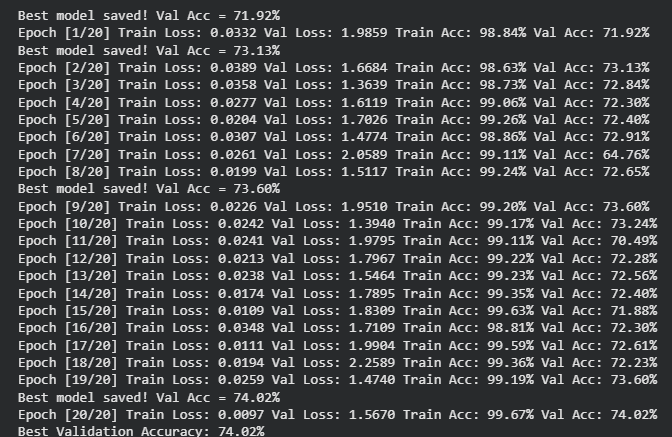

2. Results for strong data agumentation: Early stopping was also used

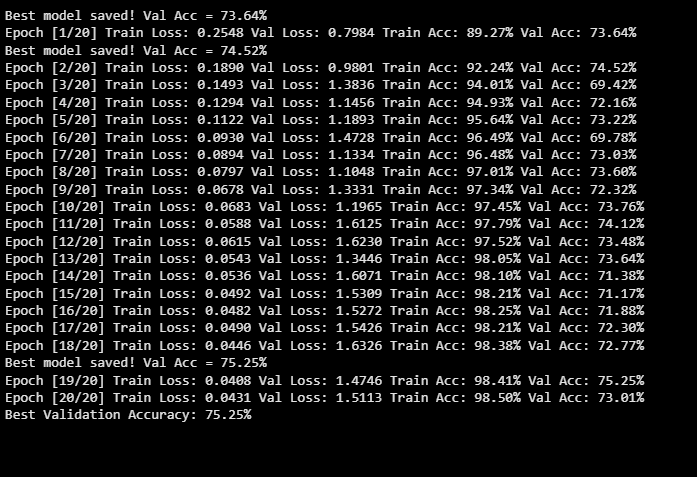





In [36]:
# =====================================
# LOAD BEST MODEL
# =====================================

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

# =====================================
# EVALUATION
# =====================================

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = (
    100 * correct
    / total
)

print(
    f"\nValidation Accuracy: "
    f"{accuracy:.2f}%"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=val_dataset.classes
    )
)



Validation Accuracy: 74.11%

Confusion Matrix:
[[1516  538]
 [ 536 1558]]

Classification Report:
              precision    recall  f1-score   support

    dementia       0.74      0.74      0.74      2054
      normal       0.74      0.74      0.74      2094

    accuracy                           0.74      4148
   macro avg       0.74      0.74      0.74      4148
weighted avg       0.74      0.74      0.74      4148



In [37]:
# =====================================
# VISUALIZE CORRECT AND INCORRECT
# =====================================

def visualize_balanced_predictions(
    model,
    val_loader,
    class_names,
    num_each=2
):

    model.eval()

    correct_dementia = []
    correct_normal = []
    incorrect = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):

                image = images[i].cpu()
                true_label = labels[i].item()
                pred_label = preds[i].item()

                true_name = class_names[true_label]
                pred_name = class_names[pred_label]

                example = (
                    image,
                    true_label,
                    pred_label
                )

                if true_label == pred_label:

                    if true_name == "dementia" and len(correct_dementia) < num_each:
                        correct_dementia.append(example)

                    elif true_name == "normal" and len(correct_normal) < num_each:
                        correct_normal.append(example)

                else:

                    if len(incorrect) < num_each:
                        incorrect.append(example)

                if (
                    len(correct_dementia) >= num_each
                    and len(correct_normal) >= num_each
                    and len(incorrect) >= num_each
                ):
                    break

            if (
                len(correct_dementia) >= num_each
                and len(correct_normal) >= num_each
                and len(incorrect) >= num_each
            ):
                break

    examples = correct_dementia + correct_normal + incorrect

    plt.figure(figsize=(12, 8))

    for idx, (image, true_label, pred_label) in enumerate(examples):

        mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(3, 1, 1)

        std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(3, 1, 1)

        image = image * std + mean
        image = image.clamp(0, 1)

        image = image.permute(1, 2, 0)

        plt.subplot(2, 3, idx + 1)
        plt.imshow(image)
        plt.axis("off")

        result = (
            "Correct"
            if true_label == pred_label
            else "Wrong"
        )

        plt.title(
            f"{result}\n"
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}"
        )

    plt.tight_layout()
    plt.show()


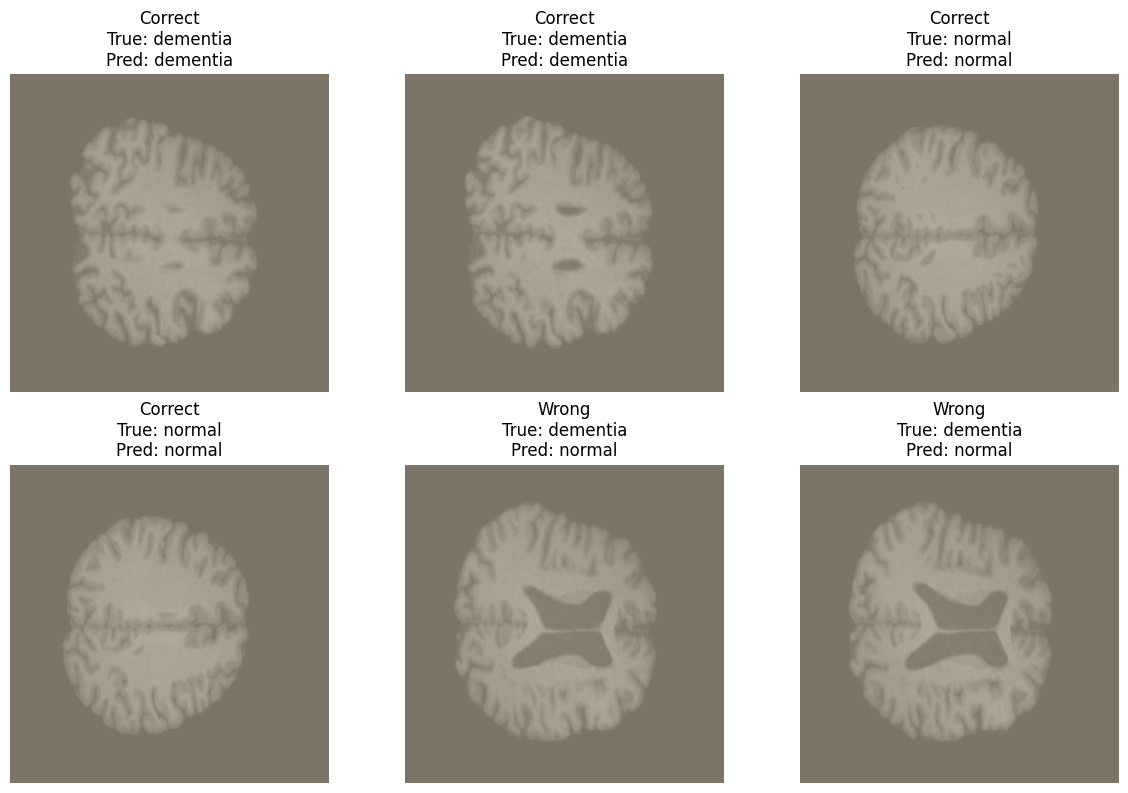

In [19]:
visualize_balanced_predictions(
    model,
    val_loader,
    val_dataset.classes,
    num_each=2
)

result of predicition:

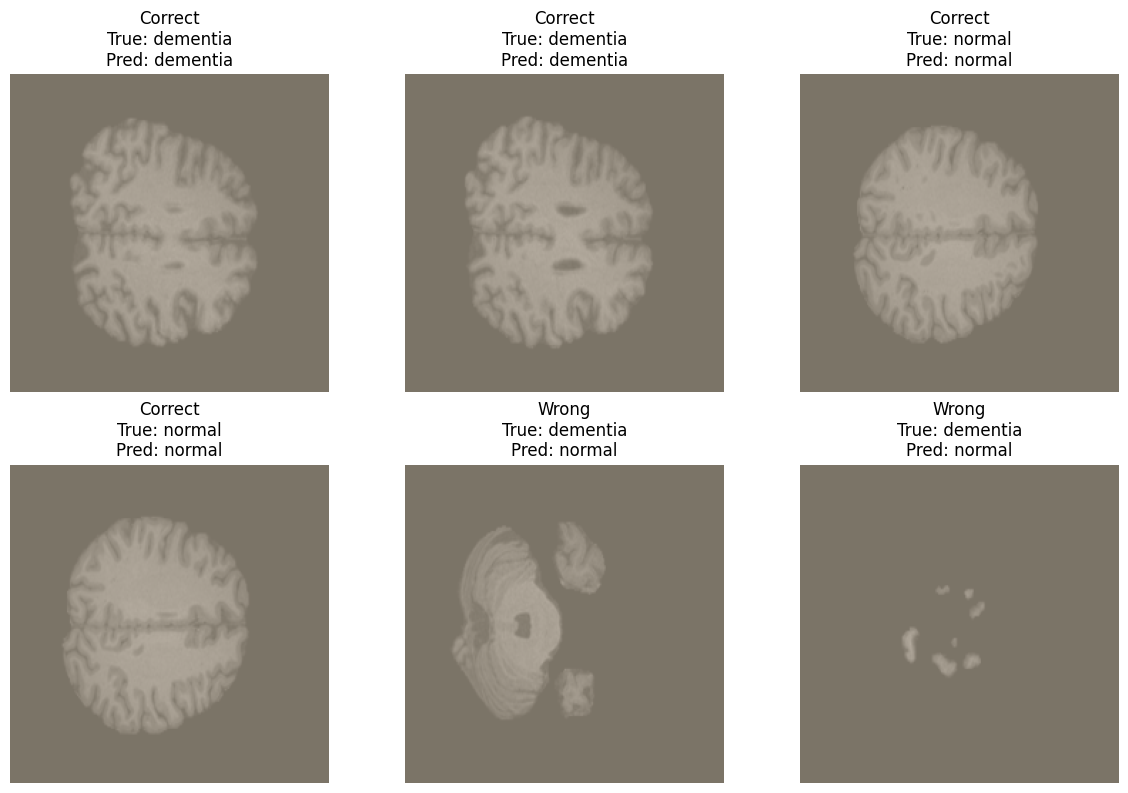



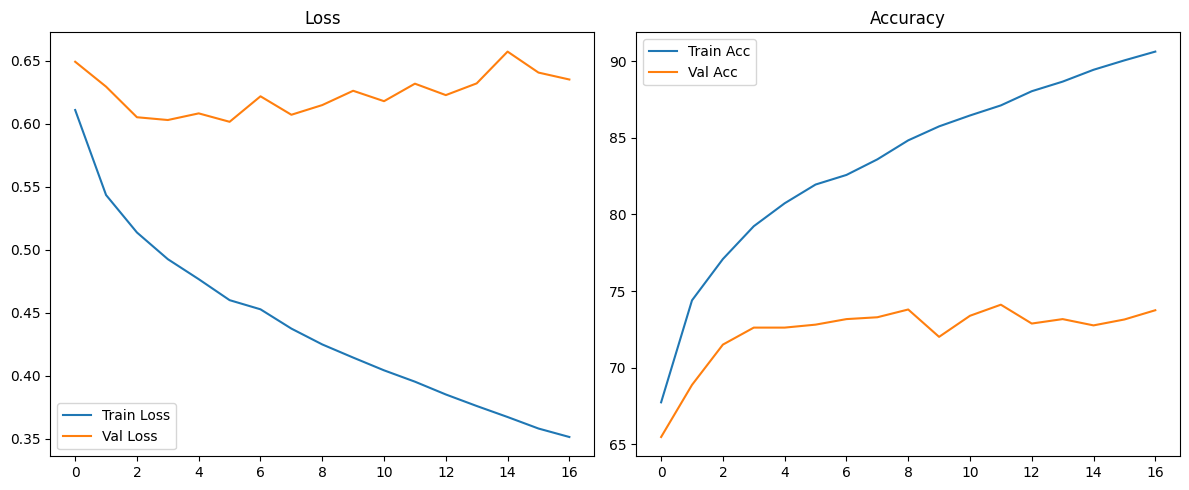

In [38]:
# =====================================
# PLOTS
# =====================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(
    train_loss_history,
    label="Train Loss"
)
plt.plot(
    val_loss_history,
    label="Val Loss"
)
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(
    train_acc_history,
    label="Train Acc"
)
plt.plot(
    val_acc_history,
    label="Val Acc"
)
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


1. For the minimal augumentation: The training accuracy rapidly increased to approximately 99%, while validation accuracy plateaued around 74%. The substantial gap between training and validation performance indicates that the model learned the training data very well but struggled to generalize to unseen subjects, suggesting overfitting
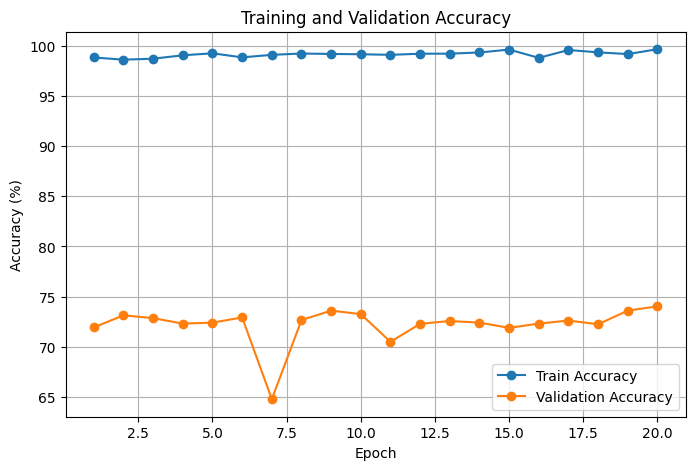


2. For stronger agumentation: The training accuracy increased steadily from 89.27% in the first epoch to 98.50% in the final epoch, indicating that the model learned the training data effectively.
In contrast, the validation accuracy fluctuated between approximately 69% and 75% throughout training, reaching its highest value of 75.25% at epoch 19

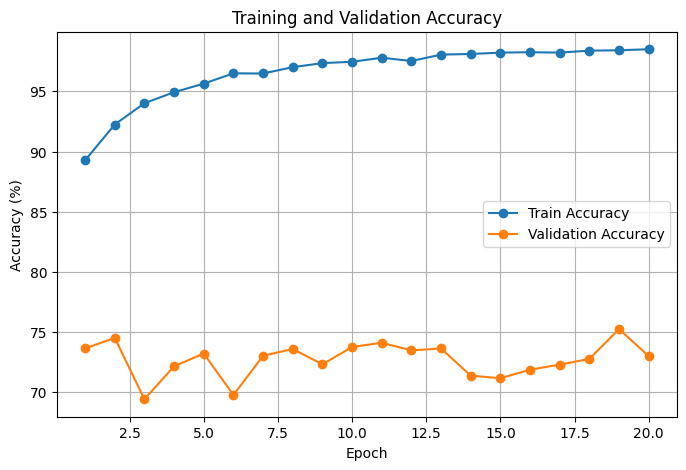

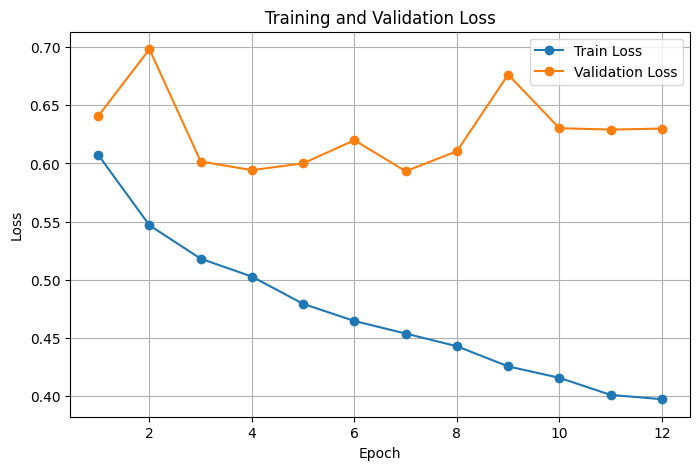

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss_history, marker="o", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("loss_curve_axis1_65_165.png", dpi=300, bbox_inches="tight")
plt.show()

1. For minimal augumention: The loss curves indicate that the model learned the training data effectively but struggled to generalize to new subject


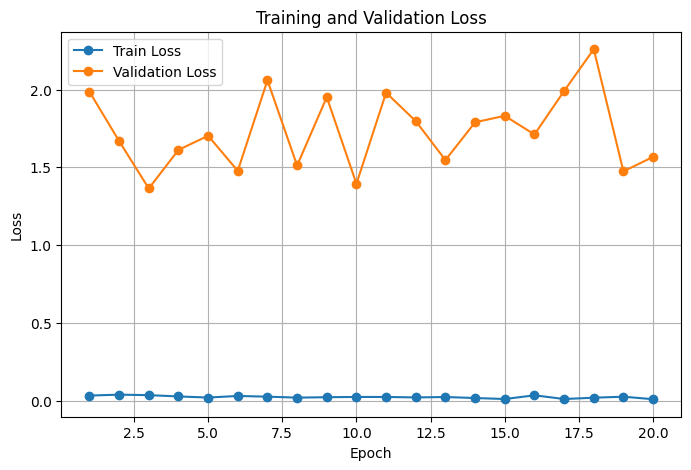


2. For stronger data agumentation: Figure X shows the training and validation loss over 20 training epochs. The training loss decreased steadily from approximately 0.25 in the first epoch to 0.04 in the final epoch, indicating that the model became increasingly effective at fitting the training data.In contrast, the validation loss increased overall from approximately 0.80 to around 1.51 and fluctuated considerably throughout training. While the model continued to improve on the training set, the validation loss did not follow the same downward trend. Instead, it became larger as training progressed. The divergence between the training and validation loss curves indicates that the model was overfitting to the training data

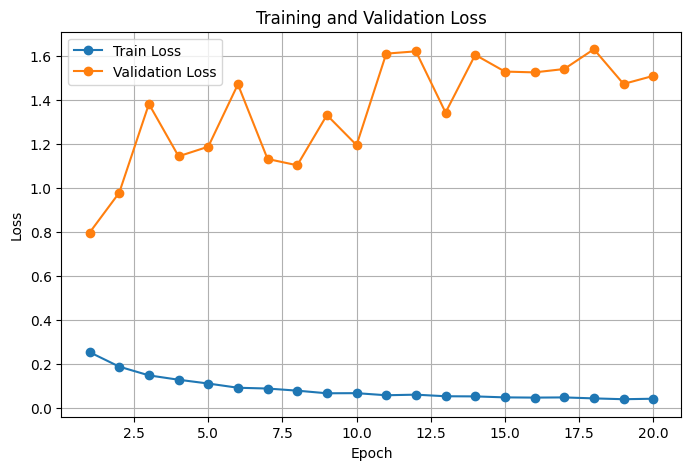

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=val_dataset.classes
    )
)

Validation Accuracy: 75.11%

Confusion Matrix:
[[1563  558]
 [ 498 1623]]

Classification Report:
              precision    recall  f1-score   support

    dementia       0.76      0.74      0.75      2121
      normal       0.74      0.77      0.75      2121

    accuracy                           0.75      4242
   macro avg       0.75      0.75      0.75      4242
weighted avg       0.75      0.75      0.75      4242



1. For minimal augumentation:

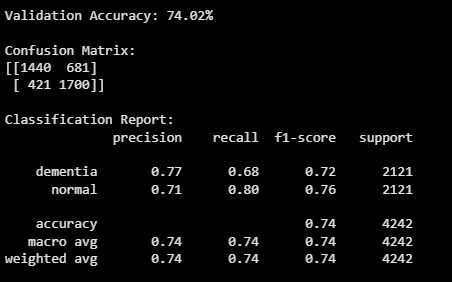

The ResNet18 model achieved a validation accuracy of 74.02% on the validation dataset. The confusion matrix showed that 1,440 dementia slices and 1,700 normal slices were correctly classified, while 681 dementia slices were misclassified as normal and 421 normal slices were misclassified as dementia.

For the dementia class, the model achieved a precision of 0.77, recall of 0.68, and F1-score of 0.72. For the normal class, the model achieved a precision of 0.71, recall of 0.80, and F1-score of 0.76. The higher recall for the normal class indicates that the model was more effective at identifying normal MRI scans than dementia scans. The lower dementia recall suggests that some dementia cases were missed and classified as normal.

Overall, the results indicate that the model was able to distinguish between dementia and normal brain MRI slices with moderate performance, achieving balanced F1-scores for both classes while showing a tendency to perform slightly better on the normal class.


2. For stronger data augumentation:


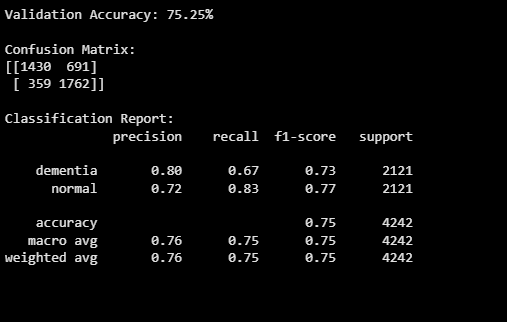

The best-performing model achieved a validation accuracy of 75.25% on the validation dataset. The confusion matrix shows that the model correctly classified 1430 dementia slices and 1762 normal slices. However, 691 dementia slices were misclassified as normal, while 359 normal slices were misclassified as dementia.

The classification report indicates that the model achieved a precision of 0.80 and a recall of 0.67 for the dementia class. This means that when the model predicted dementia, it was correct 80% of the time, but it identified only 67% of all dementia slices present in the validation set.

For the normal class, the model achieved a precision of 0.72 and a recall of 0.83, indicating that it was more effective at recognizing normal MRI slices than dementia MRI slices.

The F1-scores were 0.73 for dementia and 0.77 for normal, resulting in a weighted average F1-score of 0.75. These results suggest that although the model can distinguish between normal and dementia MRI slices reasonably well, it still misses a proportion of dementia cases and shows a tendency to classify Some dementia slices as normal.